# How Did the Drivers of USD/KRW Change After the Fed Began Tightening in March 2022?

### A regime analysis of interest-rate differentials, broad dollar strength, global risk sentiment, and regional currency movements

## Research Question
Did the factors associated with monthly USD/KRW movements change after the Federal Reserve began raising rates in March 2022?

## Starting Hypothesis
The US–Korea 3-year government-bond yield differential would become more important for USD/KRW after the Fed began tightening.

## Empirical Design
- **Sample:** January 2016 through August 2026
- **Primary frequency:** Monthly; weekly estimates are used as a robustness check
- **Regimes:** Pre-tightening (through February 2022) and post-tightening (from April 2022); March 2022 is treated as a transition month
- **Outcome:** Percentage change in USD/KRW. A positive value means the dollar strengthened and the won weakened.
- **Drivers:** Change in the matched 3-year US–Korea yield gap, DXY, VIX, and USD/CNY
- **Method:** Standardized OLS regressions with heteroskedasticity-and-autocorrelation-consistent (HAC) standard errors

## Scope and Interpretation
This is an observational regime comparison. Regression coefficients describe conditional associations, not proof that one variable caused the exchange rate to move. The starting hypothesis is tested rather than assumed.


## 1. Setup and USD/KRW Exchange Rate Data

In [ ]:
!pip install yfinance -q

import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

ANALYSIS_START = "2016-01-01"
ANALYSIS_END = "2026-08-31"
WEEKLY_END = "2026-08-28"
YAHOO_END_EXCLUSIVE = "2026-09-01"

usdkrw = yf.download(
    "KRW=X",
    start=ANALYSIS_START,
    end=YAHOO_END_EXCLUSIVE,
    auto_adjust=False,
    progress=False
)

print("Number of observations:", len(usdkrw))
display(usdkrw.head())
display(usdkrw.tail())

# Simplify Yahoo Finance's column structure
if isinstance(usdkrw.columns, pd.MultiIndex):
    usdkrw.columns = usdkrw.columns.get_level_values(0)

# Keep only the closing USD/KRW exchange rate
usdkrw_daily = usdkrw[["Close"]].copy()
usdkrw_daily.columns = ["USD_KRW"]

# Select the final available exchange rate from each week
usdkrw_weekly = (
    usdkrw_daily
    .resample("W-FRI")
    .last()
    .loc[:WEEKLY_END]
    .dropna()
)

# Calculate the percentage change from the previous week
usdkrw_weekly["Weekly_Change_Pct"] = (
    usdkrw_weekly["USD_KRW"].pct_change() * 100
)

print("Number of weekly observations:", len(usdkrw_weekly))
display(usdkrw_weekly.head())
display(usdkrw_weekly.tail())


Number of observations: 2774


Price,Adj Close,Close,High,Low,Open,Volume
Ticker,KRW=X,KRW=X,KRW=X,KRW=X,KRW=X,KRW=X
Date,,,,,,
2016-01-01,1174.109985,1174.109985,1174.109985,1172.199951,1174.109985,0
2016-01-04,1174.109985,1174.109985,1191.530029,1174.109985,1174.109985,0
2016-01-05,1187.359985,1187.359985,1191.959961,1183.000000,1188.900024,0
2016-01-06,1188.719971,1188.719971,1200.949951,1185.550049,1189.479980,0
2016-01-07,1198.739990,1198.739990,1203.199951,1189.900024,1198.680054,0


Price,Adj Close,Close,High,Low,Open,Volume
Ticker,KRW=X,KRW=X,KRW=X,KRW=X,KRW=X,KRW=X
Date,,,,,,
2026-08-25,1380.760010,1380.760010,1386.680054,1378.900024,1379.109985,0
2026-08-26,1381.489990,1381.489990,1387.930054,1381.099976,1381.160034,0
2026-08-27,1383.489990,1383.489990,1384.770020,1376.790039,1383.030029,0
2026-08-28,1380.449951,1380.449951,1381.380005,1369.739990,1381.000000,0
2026-08-31,1377.109985,1377.109985,1379.260010,1365.160034,1377.619995,0


Number of weekly observations: 557


,USD_KRW,Weekly_Change_Pct
Date,,
2016-01-01,1174.109985,NaN
2016-01-08,1195.390015,1.812439
2016-01-15,1206.439941,0.924378
2016-01-22,1202.069946,-0.362222
2016-01-29,1205.630005,0.296161


,USD_KRW,Weekly_Change_Pct
Date,,
2026-07-31,1420.599976,-3.625415
2026-08-07,1422.300049,0.119673
2026-08-14,1416.849976,-0.383187
2026-08-21,1390.790039,-1.839287
2026-08-28,1380.449951,-0.743469


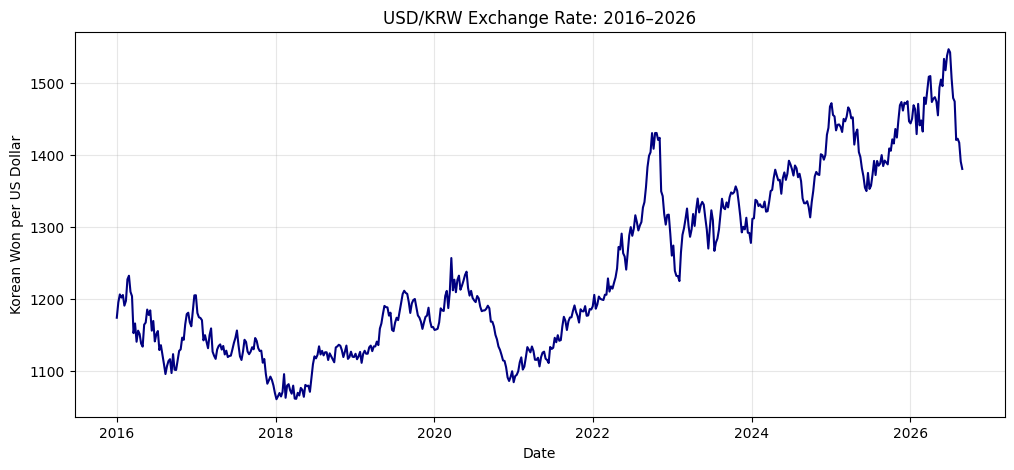

In [ ]:
plt.figure(figsize=(12, 5))

plt.plot(
    usdkrw_weekly.index,
    usdkrw_weekly["USD_KRW"],
    color="navy"
)

plt.title("USD/KRW Exchange Rate: 2016–2026")
plt.xlabel("Date")
plt.ylabel("Korean Won per US Dollar")
plt.grid(alpha=0.3)
plt.show()


## 2. Exploratory Benchmark: US 2-Year Yield

This preliminary chart introduces the link between US rates and USD/KRW. It is not the final specification because it lacks a Korean rate of the same maturity. The main analysis below uses matched US and Korean 3-year government-bond yields.


In [ ]:
!pip install pandas_datareader -q

from pandas_datareader import data as web

# Download daily US 2-year Treasury yields from FRED
us_2y = web.DataReader(
    "DGS2",
    "fred",
    start=ANALYSIS_START,
    end=ANALYSIS_END
)

# Give the column a clearer name
us_2y.columns = ["US_2Y_Yield"]

# Convert daily data into weekly Friday observations
us_2y_weekly = (
    us_2y
    .resample("W-FRI")
    .last()
    .loc[:WEEKLY_END]
)

print("Number of weekly observations:", len(us_2y_weekly))
display(us_2y_weekly.head())
display(us_2y_weekly.tail())


Number of weekly observations: 557


,US_2Y_Yield
DATE,
2016-01-01,NaN
2016-01-08,0.94
2016-01-15,0.85
2016-01-22,0.88
2016-01-29,0.76


,US_2Y_Yield
DATE,
2026-07-31,4.28
2026-08-07,4.19
2026-08-14,4.17
2026-08-21,4.24
2026-08-28,4.34


In [ ]:
# Combine USD/KRW and the US 2-year yield using matching weekly dates
market_data = usdkrw_weekly.join(us_2y_weekly, how="inner")

# Keep observations only through the last completed week
market_data = market_data.loc[:WEEKLY_END].copy()

# Calculate the weekly change in the US 2-year yield
market_data["US_2Y_Change"] = market_data["US_2Y_Yield"].diff()

# Remove rows missing required information
market_data = market_data.dropna()

print("Combined weekly observations:", len(market_data))
display(market_data.head())
display(market_data.tail())


Combined weekly observations: 555


,USD_KRW,Weekly_Change_Pct,US_2Y_Yield,US_2Y_Change
Date,,,,
2016-01-15,1206.439941,0.924378,0.85,-0.09
2016-01-22,1202.069946,-0.362222,0.88,0.03
2016-01-29,1205.630005,0.296161,0.76,-0.12
2016-02-05,1190.849976,-1.225918,0.74,-0.02
2016-02-12,1197.449951,0.554224,0.71,-0.03


,USD_KRW,Weekly_Change_Pct,US_2Y_Yield,US_2Y_Change
Date,,,,
2026-07-31,1420.599976,-3.625415,4.28,-0.05
2026-08-07,1422.300049,0.119673,4.19,-0.09
2026-08-14,1416.849976,-0.383187,4.17,-0.02
2026-08-21,1390.790039,-1.839287,4.24,0.07
2026-08-28,1380.449951,-0.743469,4.34,0.10


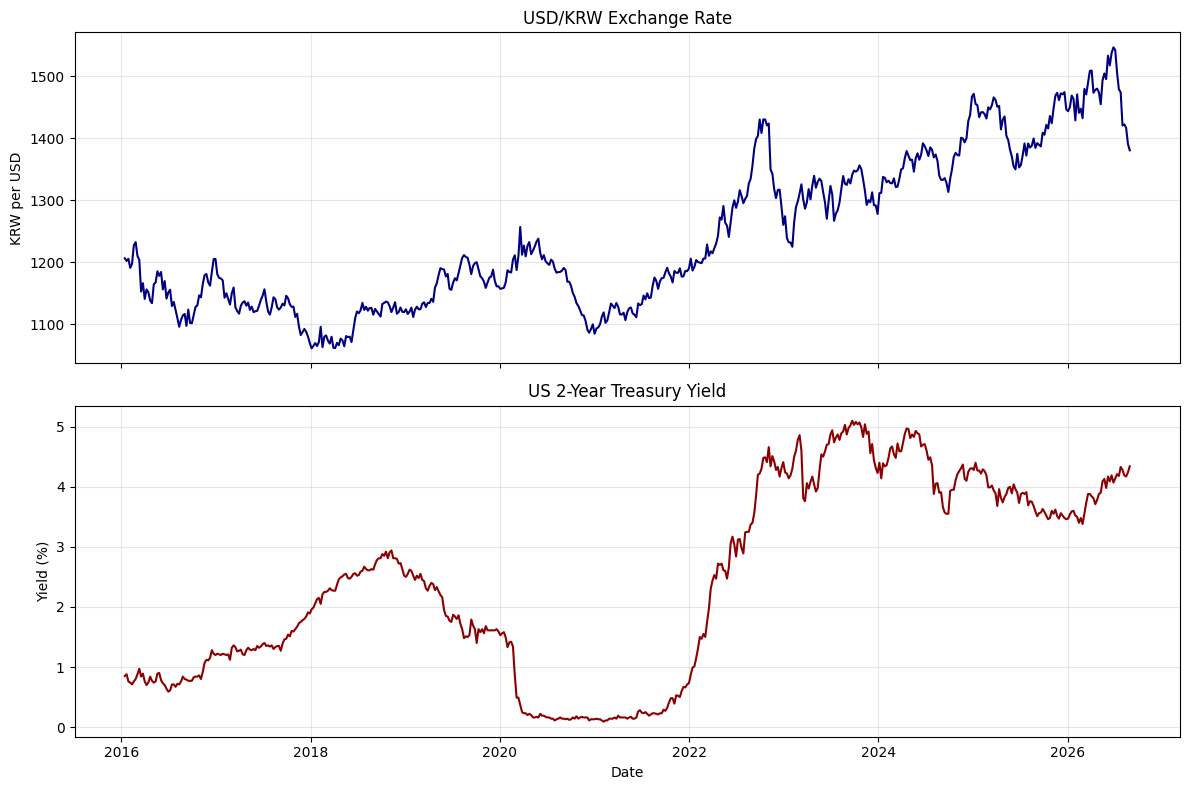

In [ ]:
fig, axes = plt.subplots(
    2,
    1,
    figsize=(12, 8),
    sharex=True
)

axes[0].plot(
    market_data.index,
    market_data["USD_KRW"],
    color="navy"
)

axes[0].set_title("USD/KRW Exchange Rate")
axes[0].set_ylabel("KRW per USD")
axes[0].grid(alpha=0.3)

axes[1].plot(
    market_data.index,
    market_data["US_2Y_Yield"],
    color="darkred"
)

axes[1].set_title("US 2-Year Treasury Yield")
axes[1].set_xlabel("Date")
axes[1].set_ylabel("Yield (%)")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


## 3. Import the Korean 3-Year Government-Bond Yield

The Korean yield series is supplied in three KOFIA-exported Excel files covering 2016–2020, 2021–2025, and 2026. Run the next cell and upload all three files. The following cell cleans dates and numeric values, removes summary rows, and combines the files.


In [ ]:
from google.colab import files

uploaded = files.upload()

print("Uploaded files:")
for file_name in uploaded.keys():
    print(file_name)


Saving Korea_3Y_2016_2020.xls to Korea_3Y_2016_2020.xls
Saving Korea_3Y_2021_2025.xls to Korea_3Y_2021_2025.xls
Saving Korea_3Y_2026.xls to Korea_3Y_2026.xls
Uploaded files:
Korea_3Y_2016_2020.xls
Korea_3Y_2021_2025.xls
Korea_3Y_2026.xls


In [ ]:
!pip install xlrd -q

korea_files = [
    "Korea_3Y_2016_2020.xls",
    "Korea_3Y_2021_2025.xls",
    "Korea_3Y_2026.xls"
]

korea_frames = []

for file_name in korea_files:
    # Read one Korean 3-year bond yield Excel file
    df = pd.read_excel(
        file_name,
        engine="xlrd"
    )

    # Give the two columns clear English names
    df.columns = [
        "Date",
        "Korea_3Y_Yield"
    ]

    # Convert valid dates and yields; invalid summary rows become missing
    df["Date"] = pd.to_datetime(
        df["Date"],
        format="%Y-%m-%d",
        errors="coerce"
    )

    df["Korea_3Y_Yield"] = pd.to_numeric(
        df["Korea_3Y_Yield"],
        errors="coerce"
    )

    # Remove summary rows such as 최고 (high) and 최저 (low)
    df = df.dropna(
        subset=["Date", "Korea_3Y_Yield"]
    )

    korea_frames.append(df)

# Stack the three periods together
korea_3y_daily = pd.concat(
    korea_frames,
    ignore_index=True
)

# Sort from oldest to newest
korea_3y_daily = korea_3y_daily.sort_values("Date")

# Remove any duplicated dates
korea_3y_daily = korea_3y_daily.drop_duplicates(
    subset="Date",
    keep="last"
)

# Use Date as the table index
korea_3y_daily = korea_3y_daily.set_index("Date")

print("Daily Korean yield observations:", len(korea_3y_daily))
display(korea_3y_daily.head())
display(korea_3y_daily.tail())


Daily Korean yield observations: 2623


,Korea_3Y_Yield
Date,
2016-01-04,1.634
2016-01-05,1.643
2016-01-06,1.639
2016-01-07,1.639
2016-01-08,1.665


,Korea_3Y_Yield
Date,
2026-08-24,3.836
2026-08-25,3.830
2026-08-26,3.816
2026-08-27,3.755
2026-08-28,3.788


In [ ]:
# Convert Korean daily yields to weekly Friday observations
korea_3y_weekly = (
    korea_3y_daily
    .resample("W-FRI")
    .last()
    .loc[:WEEKLY_END]
)

# Add Korean yields to our combined market dataset
market_data = market_data.join(
    korea_3y_weekly,
    how="inner"
)

# Calculate the US-minus-Korea short-term yield differential
market_data["Rate_Differential"] = (
    market_data["US_2Y_Yield"]
    - market_data["Korea_3Y_Yield"]
)

# Calculate how much the differential changed each week
market_data["Rate_Diff_Change"] = (
    market_data["Rate_Differential"].diff()
)

market_data = market_data.dropna()

print("Final matched weekly observations:", len(market_data))
display(market_data.head())
display(market_data.tail())


Final matched weekly observations: 552


,USD_KRW,Weekly_Change_Pct,US_2Y_Yield,US_2Y_Change,Korea_3Y_Yield,Rate_Differential,Rate_Diff_Change
Date,,,,,,,
2016-01-22,1202.069946,-0.362222,0.88,0.03,1.621,-0.741,0.057
2016-01-29,1205.630005,0.296161,0.76,-0.12,1.564,-0.804,-0.063
2016-02-05,1190.849976,-1.225918,0.74,-0.02,1.506,-0.766,0.038
2016-02-12,1197.449951,0.554224,0.71,-0.03,1.475,-0.765,0.001
2016-02-19,1227.400024,2.501154,0.76,0.05,1.468,-0.708,0.057


,USD_KRW,Weekly_Change_Pct,US_2Y_Yield,US_2Y_Change,Korea_3Y_Yield,Rate_Differential,Rate_Diff_Change
Date,,,,,,,
2026-07-31,1420.599976,-3.625415,4.28,-0.05,3.758,0.522,0.151
2026-08-07,1422.300049,0.119673,4.19,-0.09,3.746,0.444,-0.078
2026-08-14,1416.849976,-0.383187,4.17,-0.02,3.796,0.374,-0.070
2026-08-21,1390.790039,-1.839287,4.24,0.07,3.854,0.386,0.012
2026-08-28,1380.449951,-0.743469,4.34,0.10,3.788,0.552,0.166


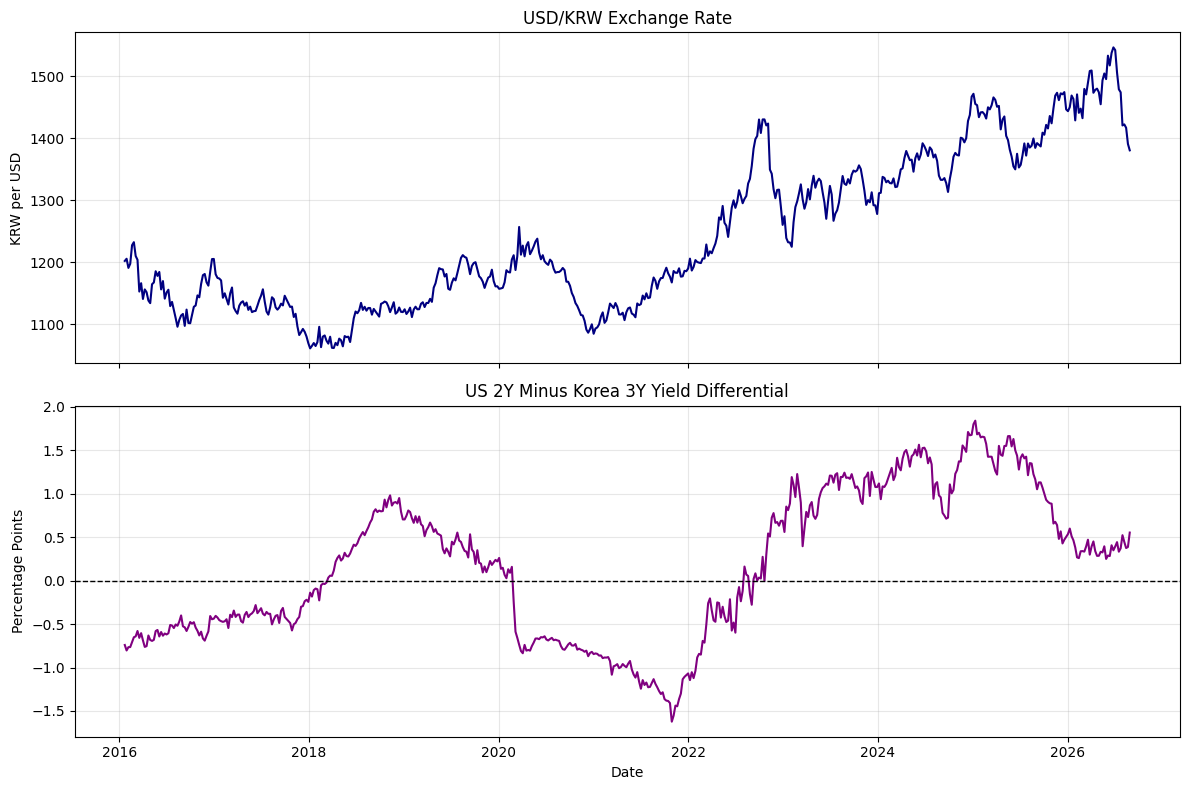

In [ ]:
fig, axes = plt.subplots(
    2,
    1,
    figsize=(12, 8),
    sharex=True
)

axes[0].plot(
    market_data.index,
    market_data["USD_KRW"],
    color="navy"
)

axes[0].set_title("USD/KRW Exchange Rate")
axes[0].set_ylabel("KRW per USD")
axes[0].grid(alpha=0.3)

axes[1].plot(
    market_data.index,
    market_data["Rate_Differential"],
    color="purple"
)

# Add a line showing where US and Korean yields are equal
axes[1].axhline(
    y=0,
    color="black",
    linestyle="--",
    linewidth=1
)

axes[1].set_title("US 2Y Minus Korea 3Y Yield Differential")
axes[1].set_xlabel("Date")
axes[1].set_ylabel("Percentage Points")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


## 4. Construct a Maturity-Matched 3-Year Yield Differential

Comparing yields with the same maturity avoids mixing different parts of the yield curve. The main rate variable is:

$$\text{Rate Differential}_t = \text{US 3Y Yield}_t - \text{Korea 3Y Yield}_t$$

A rise means the US 3-year yield increased relative to Korea's 3-year yield.


In [ ]:
# Download the maturity-matched US 3-year Treasury yield
us_3y = web.DataReader(
    "DGS3",
    "fred",
    start=ANALYSIS_START,
    end=ANALYSIS_END
)

us_3y.columns = ["US_3Y_Yield"]

# Convert daily observations to weekly Friday observations
us_3y_weekly = (
    us_3y
    .resample("W-FRI")
    .last()
    .loc[:WEEKLY_END]
)

display(us_3y_weekly.head())
display(us_3y_weekly.tail())


,US_3Y_Yield
DATE,
2016-01-01,NaN
2016-01-08,1.20
2016-01-15,1.08
2016-01-22,1.11
2016-01-29,0.97


,US_3Y_Yield
DATE,
2026-07-31,4.34
2026-08-07,4.25
2026-08-14,4.24
2026-08-21,4.31
2026-08-28,4.41


In [ ]:
# Add the US 3-year yield to the dataset
market_data = market_data.join(
    us_3y_weekly,
    how="inner"
)

# Primary maturity-matched differential
market_data["Rate_Differential"] = (
    market_data["US_3Y_Yield"]
    - market_data["Korea_3Y_Yield"]
)

market_data["Rate_Diff_Change"] = (
    market_data["Rate_Differential"].diff()
)

market_data = market_data.dropna()

display(
    market_data[
        [
            "USD_KRW",
            "US_3Y_Yield",
            "Korea_3Y_Yield",
            "Rate_Differential"
        ]
    ].tail()
)


,USD_KRW,US_3Y_Yield,Korea_3Y_Yield,Rate_Differential
2026-07-31,1420.599976,4.34,3.758,0.582
2026-08-07,1422.300049,4.25,3.746,0.504
2026-08-14,1416.849976,4.24,3.796,0.444
2026-08-21,1390.790039,4.31,3.854,0.456
2026-08-28,1380.449951,4.41,3.788,0.622


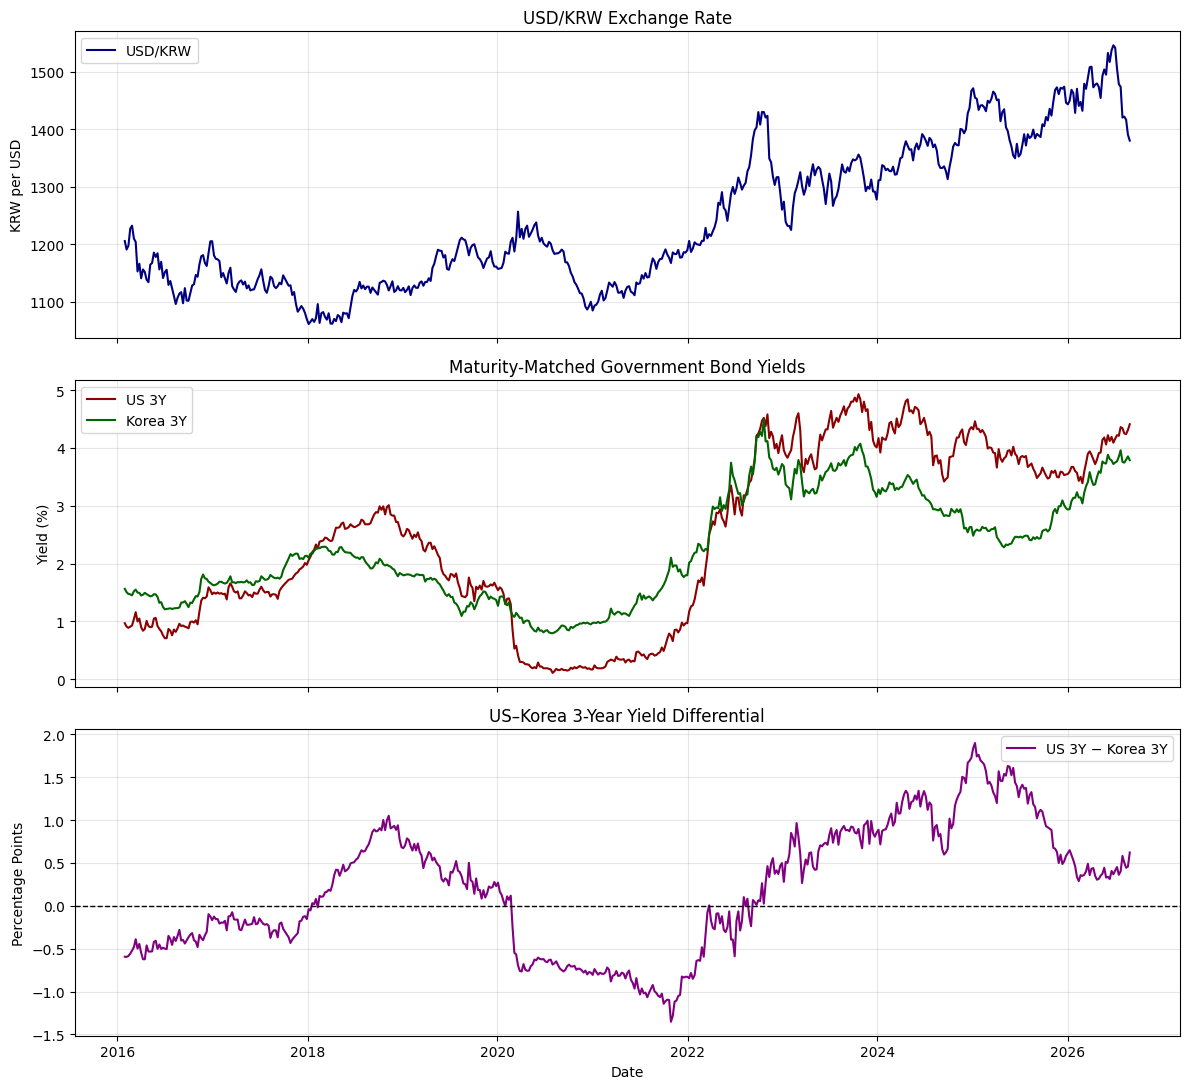

In [ ]:
fig, axes = plt.subplots(
    3,
    1,
    figsize=(12, 11),
    sharex=True
)

# USD/KRW
axes[0].plot(
    market_data.index,
    market_data["USD_KRW"],
    color="navy",
    label="USD/KRW"
)

axes[0].set_title("USD/KRW Exchange Rate")
axes[0].set_ylabel("KRW per USD")
axes[0].legend()
axes[0].grid(alpha=0.3)

# US and Korean 3-year yields
axes[1].plot(
    market_data.index,
    market_data["US_3Y_Yield"],
    color="darkred",
    label="US 3Y"
)

axes[1].plot(
    market_data.index,
    market_data["Korea_3Y_Yield"],
    color="darkgreen",
    label="Korea 3Y"
)

axes[1].set_title("Maturity-Matched Government Bond Yields")
axes[1].set_ylabel("Yield (%)")
axes[1].legend()
axes[1].grid(alpha=0.3)

# US minus Korea rate differential
axes[2].plot(
    market_data.index,
    market_data["Rate_Differential"],
    color="purple",
    label="US 3Y − Korea 3Y"
)

axes[2].axhline(
    y=0,
    color="black",
    linestyle="--",
    linewidth=1
)

axes[2].set_title("US–Korea 3-Year Yield Differential")
axes[2].set_xlabel("Date")
axes[2].set_ylabel("Percentage Points")
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()


## 5. Add Competing Market Drivers

The rate gap is tested alongside three plausible competing explanations:

| Variable | Definition | Expected interpretation when it rises |
|---|---|---|
| **DXY** | Broad value of the US dollar against major currencies | A stronger global dollar may raise USD/KRW |
| **VIX** | Market-implied US equity volatility, often used as a risk-aversion proxy | Risk-off conditions may weaken the won |
| **USD/CNY** | Chinese yuan per US dollar | A weaker yuan may coincide with a weaker won because of regional and trade linkages |

These controls help isolate whether the yield gap has information beyond broad dollar, risk, and regional-currency movements.


In [ ]:
def download_yahoo_close(ticker, column_name):
    data = yf.download(
        ticker,
        start=ANALYSIS_START,
        end=YAHOO_END_EXCLUSIVE,
        auto_adjust=False,
        progress=False
    )

    close = data["Close"]

    # Handle Yahoo Finance's multi-level column format
    if isinstance(close, pd.DataFrame):
        close = close.iloc[:, 0]

    return close.rename(column_name).to_frame()


# Broad US dollar index
dxy_daily = download_yahoo_close(
    "DX-Y.NYB",
    "DXY"
)

# VIX fear index
vix_daily = download_yahoo_close(
    "^VIX",
    "VIX"
)

# Chinese yuan per US dollar
usdcny_daily = download_yahoo_close(
    "CNY=X",
    "USD_CNY"
)

display(dxy_daily.head())
display(vix_daily.head())
display(usdcny_daily.head())


,DXY
Date,
2016-01-04,98.870003
2016-01-05,99.400002
2016-01-06,99.180000
2016-01-07,98.220001
2016-01-08,98.540001


,VIX
Date,
2016-01-04,20.700001
2016-01-05,19.340000
2016-01-06,20.590000
2016-01-07,24.990000
2016-01-08,27.010000


,USD_CNY
Date,
2016-01-01,6.4837
2016-01-04,6.4837
2016-01-05,6.5254
2016-01-06,6.5125
2016-01-07,6.5467


## 6. Build the Primary Monthly Dataset and Regime Split

Daily series are converted to month-end observations. March 2022 is excluded as the transition month because the Fed's first rate increase occurred during that month. This avoids assigning the same month wholly to either regime.

### Variable definitions

| Model field | Definition |
|---|---|
| `USD_KRW_Change_Pct` | Monthly percentage change in won per US dollar; positive = won depreciation |
| `Rate_Diff_Change` | Monthly percentage-point change in US 3Y minus Korea 3Y yield |
| `DXY_Change_Pct` | Monthly percentage change in DXY |
| `VIX_Change_Pct` | Monthly percentage change in VIX |
| `USD_CNY_Change_Pct` | Monthly percentage change in yuan per US dollar |

Standardized coefficients are used later so effect sizes can be compared across variables measured in different units.


In [ ]:
daily_series = [
    usdkrw_daily,
    us_3y,
    korea_3y_daily,
    dxy_daily,
    vix_daily,
    usdcny_daily
]

monthly_data = pd.concat(daily_series, axis=1)
monthly_data = monthly_data.resample("ME").last()
monthly_data = monthly_data.loc[:ANALYSIS_END].copy()

monthly_data["Rate_Differential"] = (
    monthly_data["US_3Y_Yield"] -
    monthly_data["Korea_3Y_Yield"]
)

change_columns = {
    "USD_KRW": "USD_KRW_Change_Pct",
    "DXY": "DXY_Change_Pct",
    "VIX": "VIX_Change_Pct",
    "USD_CNY": "USD_CNY_Change_Pct"
}

for original, change in change_columns.items():
    monthly_data[change] = monthly_data[original].pct_change() * 100

monthly_data["Rate_Diff_Change"] = (
    monthly_data["Rate_Differential"].diff()
)

monthly_data = monthly_data.dropna().copy()

monthly_data["Regime"] = "Transition Month"
monthly_data.loc[
    monthly_data.index < "2022-03-01", "Regime"
] = "Pre-Tightening"
monthly_data.loc[
    monthly_data.index >= "2022-04-01", "Regime"
] = "Post-Tightening"

print("Monthly observations:", len(monthly_data))
display(monthly_data.tail(10))


Monthly observations: 127


,USD_KRW,US_3Y_Yield,Korea_3Y_Yield,DXY,VIX,USD_CNY,Rate_Differential,USD_KRW_Change_Pct,DXY_Change_Pct,VIX_Change_Pct,USD_CNY_Change_Pct,Rate_Diff_Change,Regime
2025-11-30,1461.400024,3.49,2.991,99.459999,16.350000,7.0758,0.499,2.624963,-0.340685,-6.250001,-0.478212,-0.385,Post-Tightening
2025-12-31,1437.910034,3.55,2.953,98.279999,14.950000,6.9961,0.597,-1.607362,-1.186407,-8.562694,-1.126374,0.098,Post-Tightening
2026-01-31,1428.760010,3.60,3.138,96.989998,17.440001,6.9480,0.462,-0.636342,-1.312577,16.655523,-0.687526,-0.135,Post-Tightening
2026-02-28,1432.319946,3.39,3.041,97.610001,19.860001,6.8409,0.349,0.249163,0.639244,13.876147,-1.541451,-0.113,Post-Tightening
2026-03-31,1516.130005,3.81,3.552,99.959999,25.250000,6.9116,0.258,5.851350,2.407539,27.139976,1.033492,-0.091,Post-Tightening
2026-04-30,1487.380005,3.91,3.595,98.080002,16.889999,6.8375,0.315,-1.896275,-1.880750,-33.108913,-1.072111,0.057,Post-Tightening
2026-05-31,1495.290039,4.06,3.731,98.910004,15.320000,6.7795,0.329,0.531810,0.846250,-9.295440,-0.848265,0.014,Post-Tightening
2026-06-30,1541.729980,4.15,3.703,101.190002,16.450001,6.7936,0.447,3.105748,2.305125,7.375986,0.207981,0.118,Post-Tightening
2026-07-31,1420.599976,4.34,3.758,99.800003,15.990000,6.7550,0.582,-7.856759,-1.373653,-2.796358,-0.568181,0.135,Post-Tightening
2026-08-31,1377.109985,4.40,3.788,99.430000,14.920000,6.7260,0.612,-3.061382,-0.370744,-6.691680,-0.429316,0.030,Post-Tightening


### 6.1 Baseline Model: Rate Differential Only

In [ ]:
import statsmodels.api as sm

# Exclude March 2022 because it is the transition month
model_data = monthly_data[
    monthly_data["Regime"] != "Transition Month"
].copy()

results = []

for regime in ["Pre-Tightening", "Post-Tightening"]:
    sample = model_data[
        model_data["Regime"] == regime
    ]

    y = sample["USD_KRW_Change_Pct"]
    X = sample[["Rate_Diff_Change"]]
    X = sm.add_constant(X)

    model = sm.OLS(y, X).fit(
        cov_type="HAC",
        cov_kwds={"maxlags": 3}
    )

    results.append({
        "Regime": regime,
        "Months": len(sample),
        "Rate_Gap_Coefficient": model.params["Rate_Diff_Change"],
        "P_Value": model.pvalues["Rate_Diff_Change"],
        "R_Squared": model.rsquared
    })

rate_model_results = pd.DataFrame(results)
display(rate_model_results.round(4))


,Regime,Months,Rate_Gap_Coefficient,P_Value,R_Squared
0,Pre-Tightening,73,1.2974,0.4298,0.0072
1,Post-Tightening,53,0.9591,0.6732,0.0029


### 6.2 Multi-Driver Model: Rate Differential, DXY, VIX, USD/CNY

In [ ]:
drivers = [
    "Rate_Diff_Change",
    "DXY_Change_Pct",
    "VIX_Change_Pct",
    "USD_CNY_Change_Pct"
]

coefficient_results = []
model_results = []

for regime in ["Pre-Tightening", "Post-Tightening"]:
    sample = model_data[
        model_data["Regime"] == regime
    ].copy()

    # Standardize the outcome and explanatory variables
    y = sample["USD_KRW_Change_Pct"]
    y = (y - y.mean()) / y.std()

    X = sample[drivers]
    X = (X - X.mean()) / X.std()
    X = sm.add_constant(X)

    model = sm.OLS(y, X).fit(
        cov_type="HAC",
        cov_kwds={"maxlags": 3}
    )

    model_results.append({
        "Regime": regime,
        "Months": len(sample),
        "R_Squared": model.rsquared,
        "Adjusted_R_Squared": model.rsquared_adj
    })

    for driver in drivers:
        coefficient_results.append({
            "Regime": regime,
            "Driver": driver,
            "Standardized_Coefficient": model.params[driver],
            "P_Value": model.pvalues[driver]
        })

model_summary = pd.DataFrame(model_results)
coefficient_table = pd.DataFrame(coefficient_results)

display(model_summary.round(4))
display(coefficient_table.round(4))


,Regime,Months,R_Squared,Adjusted_R_Squared
0,Pre-Tightening,73,0.3999,0.3646
1,Post-Tightening,53,0.7021,0.6773


,Regime,Driver,Standardized_Coefficient,P_Value
0,Pre-Tightening,Rate_Diff_Change,0.0672,0.1785
1,Pre-Tightening,DXY_Change_Pct,0.3656,0.0069
2,Pre-Tightening,VIX_Change_Pct,0.1889,0.0004
3,Pre-Tightening,USD_CNY_Change_Pct,0.2590,0.0059
4,Post-Tightening,Rate_Diff_Change,-0.2387,0.0021
5,Post-Tightening,DXY_Change_Pct,0.5720,0.0000
6,Post-Tightening,VIX_Change_Pct,0.1038,0.2405
7,Post-Tightening,USD_CNY_Change_Pct,0.3460,0.0000


### Reading the Main Monthly Results

- **Before tightening:** The yield-gap change is not statistically significant. DXY, VIX, and USD/CNY show stronger conditional associations with USD/KRW.
- **Bivariate check:** In the simple rate-only regression (Section 6.1, no controls), the yield-gap change is not significant in either regime. The post-tightening significance reported above only emerges once DXY, VIX, and USD/CNY are added as controls in the multi-driver model — it is a conditional result, not a raw bivariate one.
- **After tightening:** The conditional yield-gap coefficient becomes statistically significant, but it is negative. This does not support a simple claim that a wider US yield advantage mechanically weakens the won.
- **Most consistent result:** DXY is the largest standardized driver after tightening, while USD/CNY also remains important.
- **Model fit:** The expanded model explains substantially more monthly variation after tightening than before it.

The evidence therefore suggests a change in the market regime, but the yield result must be tested for timing, outliers, and data frequency before drawing a conclusion.


### 6.3 Incremental Model Building

In [ ]:
model_specifications = {
    "1. Rate only": [
        "Rate_Diff_Change"
    ],
    "2. Add DXY": [
        "Rate_Diff_Change",
        "DXY_Change_Pct"
    ],
    "3. Add VIX": [
        "Rate_Diff_Change",
        "DXY_Change_Pct",
        "VIX_Change_Pct"
    ],
    "4. Add USD/CNY": [
        "Rate_Diff_Change",
        "DXY_Change_Pct",
        "VIX_Change_Pct",
        "USD_CNY_Change_Pct"
    ]
}

incremental_results = []

for regime in ["Pre-Tightening", "Post-Tightening"]:
    sample = model_data[
        model_data["Regime"] == regime
    ].copy()

    y = sample["USD_KRW_Change_Pct"]
    y = (y - y.mean()) / y.std()

    for model_name, variables in model_specifications.items():
        X = sample[variables]
        X = (X - X.mean()) / X.std()
        X = sm.add_constant(X)

        model = sm.OLS(y, X).fit(
            cov_type="HAC",
            cov_kwds={"maxlags": 3}
        )

        incremental_results.append({
            "Regime": regime,
            "Model": model_name,
            "Rate_Coefficient": model.params["Rate_Diff_Change"],
            "Rate_P_Value": model.pvalues["Rate_Diff_Change"],
            "R_Squared": model.rsquared,
            "Adjusted_R_Squared": model.rsquared_adj
        })

incremental_table = pd.DataFrame(incremental_results)
display(incremental_table.round(4))


,Regime,Model,Rate_Coefficient,Rate_P_Value,R_Squared,Adjusted_R_Squared
0,Pre-Tightening,1. Rate only,0.0846,0.4298,0.0072,-0.0068
1,Pre-Tightening,2. Add DXY,0.0172,0.7993,0.3274,0.3082
2,Pre-Tightening,3. Add VIX,0.0441,0.4347,0.3551,0.3270
3,Pre-Tightening,4. Add USD/CNY,0.0672,0.1785,0.3999,0.3646
4,Post-Tightening,1. Rate only,0.0536,0.6732,0.0029,-0.0167
5,Post-Tightening,2. Add DXY,-0.2352,0.0008,0.6158,0.6005
6,Post-Tightening,3. Add VIX,-0.1977,0.0085,0.6293,0.6066
7,Post-Tightening,4. Add USD/CNY,-0.2387,0.0021,0.7021,0.6773


### 6.4 Multicollinearity Check (VIF)

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

for regime in ["Pre-Tightening", "Post-Tightening"]:
    sample = model_data[
        model_data["Regime"] == regime
    ]

    X = sample[drivers].dropna()
    X = (X - X.mean()) / X.std()

    vif_table = pd.DataFrame({
        "Variable": X.columns,
        "VIF": [
            variance_inflation_factor(X.values, i)
            for i in range(len(X.columns))
        ]
    })

    print(regime)
    display(X.corr().round(3))
    display(vif_table.round(2))


Pre-Tightening


,Rate_Diff_Change,DXY_Change_Pct,VIX_Change_Pct,USD_CNY_Change_Pct
Rate_Diff_Change,1.000,0.118,-0.120,-0.012
DXY_Change_Pct,0.118,1.000,0.272,0.568
VIX_Change_Pct,-0.120,0.272,1.000,0.118
USD_CNY_Change_Pct,-0.012,0.568,0.118,1.000


,Variable,VIF
0,Rate_Diff_Change,1.05
1,DXY_Change_Pct,1.63
2,VIX_Change_Pct,1.11
3,USD_CNY_Change_Pct,1.50


Post-Tightening


,Rate_Diff_Change,DXY_Change_Pct,VIX_Change_Pct,USD_CNY_Change_Pct
Rate_Diff_Change,1.000,0.346,-0.066,0.292
DXY_Change_Pct,0.346,1.000,0.494,0.614
VIX_Change_Pct,-0.066,0.494,1.000,0.353
USD_CNY_Change_Pct,0.292,0.614,0.353,1.000


,Variable,VIF
0,Rate_Diff_Change,1.26
1,DXY_Change_Pct,2.08
2,VIX_Change_Pct,1.46
3,USD_CNY_Change_Pct,1.64


## 7. Robustness Checks

### 7.1 Splitting the Differential into US and Korea Legs

In [ ]:
# Monthly change in each country's 3-year yield
monthly_data["US_3Y_Change"] = monthly_data["US_3Y_Yield"].diff()
monthly_data["Korea_3Y_Change"] = monthly_data["Korea_3Y_Yield"].diff()

split_drivers = [
    "US_3Y_Change",
    "Korea_3Y_Change",
    "DXY_Change_Pct",
    "VIX_Change_Pct",
    "USD_CNY_Change_Pct"
]

split_results = []

for regime in ["Pre-Tightening", "Post-Tightening"]:

    sample = monthly_data[
        monthly_data["Regime"] == regime
    ].dropna(subset=["USD_KRW_Change_Pct"] + split_drivers)

    # Standardize variables so coefficient sizes can be compared
    y = sample["USD_KRW_Change_Pct"]
    y = (y - y.mean()) / y.std()

    X = sample[split_drivers]
    X = (X - X.mean()) / X.std()
    X = sm.add_constant(X)

    model = sm.OLS(y, X).fit(
        cov_type="HAC",
        cov_kwds={"maxlags": 3}
    )

    for driver in split_drivers:
        split_results.append({
            "Regime": regime,
            "Driver": driver,
            "Standardized_Coefficient": model.params[driver],
            "P_Value": model.pvalues[driver],
            "R_Squared": model.rsquared
        })

split_table = pd.DataFrame(split_results)

display(split_table.round(4))


,Regime,Driver,Standardized_Coefficient,P_Value,R_Squared
0,Pre-Tightening,US_3Y_Change,0.0845,0.2536,0.4290
1,Pre-Tightening,Korea_3Y_Change,-0.0118,0.8636,0.4290
2,Pre-Tightening,DXY_Change_Pct,0.3752,0.0100,0.4290
3,Pre-Tightening,VIX_Change_Pct,0.2000,0.0013,0.4290
4,Pre-Tightening,USD_CNY_Change_Pct,0.2754,0.0043,0.4290
5,Post-Tightening,US_3Y_Change,-0.3907,0.0088,0.7022
6,Post-Tightening,Korea_3Y_Change,0.3527,0.0014,0.7022
7,Post-Tightening,DXY_Change_Pct,0.5651,0.0000,0.7022
8,Post-Tightening,VIX_Change_Pct,0.1019,0.2588,0.7022
9,Post-Tightening,USD_CNY_Change_Pct,0.3423,0.0001,0.7022


### 7.2 Testing Lagged Yield Changes

In [ ]:
# Create one-month-lagged yield changes
monthly_data["US_3Y_Change_Lag1"] = monthly_data["US_3Y_Change"].shift(1)
monthly_data["Korea_3Y_Change_Lag1"] = monthly_data["Korea_3Y_Change"].shift(1)

lagged_drivers = [
    "US_3Y_Change_Lag1",
    "Korea_3Y_Change_Lag1",
    "DXY_Change_Pct",
    "VIX_Change_Pct",
    "USD_CNY_Change_Pct"
]

lagged_results = []

for regime in ["Pre-Tightening", "Post-Tightening"]:

    sample = monthly_data[
        monthly_data["Regime"] == regime
    ].dropna(subset=["USD_KRW_Change_Pct"] + lagged_drivers)

    # Standardize variables for coefficient comparison
    y = sample["USD_KRW_Change_Pct"]
    y = (y - y.mean()) / y.std()

    X = sample[lagged_drivers]
    X = (X - X.mean()) / X.std()
    X = sm.add_constant(X)

    # HAC standard errors are more appropriate for monthly time-series data
    model = sm.OLS(y, X).fit(
        cov_type="HAC",
        cov_kwds={"maxlags": 3}
    )

    for driver in lagged_drivers:
        lagged_results.append({
            "Regime": regime,
            "Driver": driver,
            "Standardized_Coefficient": model.params[driver],
            "P_Value": model.pvalues[driver],
            "R_Squared": model.rsquared,
            "Adjusted_R_Squared": model.rsquared_adj
        })

lagged_table = pd.DataFrame(lagged_results)

display(lagged_table.round(4))


,Regime,Driver,Standardized_Coefficient,P_Value,R_Squared,Adjusted_R_Squared
0,Pre-Tightening,US_3Y_Change_Lag1,-0.0846,0.3121,0.3942,0.3476
1,Pre-Tightening,Korea_3Y_Change_Lag1,0.0327,0.7524,0.3942,0.3476
2,Pre-Tightening,DXY_Change_Pct,0.3444,0.0066,0.3942,0.3476
3,Pre-Tightening,VIX_Change_Pct,0.1711,0.0039,0.3942,0.3476
4,Pre-Tightening,USD_CNY_Change_Pct,0.3044,0.0083,0.3942,0.3476
5,Post-Tightening,US_3Y_Change_Lag1,-0.2530,0.0373,0.6849,0.6514
6,Post-Tightening,Korea_3Y_Change_Lag1,0.1077,0.3553,0.6849,0.6514
7,Post-Tightening,DXY_Change_Pct,0.4525,0.0000,0.6849,0.6514
8,Post-Tightening,VIX_Change_Pct,0.1460,0.0609,0.6849,0.6514
9,Post-Tightening,USD_CNY_Change_Pct,0.3773,0.0000,0.6849,0.6514


### 7.3 Staged Model Building (Post-Tightening Period)

In [ ]:
# Use only the post-tightening period
# Keep one identical sample across every model for a fair comparison
post_sample = monthly_data[
    monthly_data["Regime"] == "Post-Tightening"
].dropna(subset=[
    "USD_KRW_Change_Pct",
    "US_3Y_Change_Lag1",
    "Korea_3Y_Change_Lag1",
    "DXY_Change_Pct",
    "VIX_Change_Pct",
    "USD_CNY_Change_Pct"
]).copy()

# Standardize the outcome variable
y = post_sample["USD_KRW_Change_Pct"]
y = (y - y.mean()) / y.std()

# Add explanatory variables in stages
staged_models = {
    "1. US yield only": [
        "US_3Y_Change_Lag1"
    ],
    "2. Add Korea yield": [
        "US_3Y_Change_Lag1",
        "Korea_3Y_Change_Lag1"
    ],
    "3. Add DXY": [
        "US_3Y_Change_Lag1",
        "Korea_3Y_Change_Lag1",
        "DXY_Change_Pct"
    ],
    "4. Add VIX": [
        "US_3Y_Change_Lag1",
        "Korea_3Y_Change_Lag1",
        "DXY_Change_Pct",
        "VIX_Change_Pct"
    ],
    "5. Add USD/CNY": [
        "US_3Y_Change_Lag1",
        "Korea_3Y_Change_Lag1",
        "DXY_Change_Pct",
        "VIX_Change_Pct",
        "USD_CNY_Change_Pct"
    ]
}

staged_results = []

for model_name, variables in staged_models.items():

    X = post_sample[variables]
    X = (X - X.mean()) / X.std()
    X = sm.add_constant(X)

    model = sm.OLS(y, X).fit(
        cov_type="HAC",
        cov_kwds={"maxlags": 3}
    )

    staged_results.append({
        "Model": model_name,
        "US_Yield_Coefficient":
            model.params["US_3Y_Change_Lag1"],
        "US_Yield_P_Value":
            model.pvalues["US_3Y_Change_Lag1"],
        "R_Squared": model.rsquared,
        "Adjusted_R_Squared": model.rsquared_adj
    })

staged_lag_table = pd.DataFrame(staged_results)

display(staged_lag_table.round(4))


,Model,US_Yield_Coefficient,US_Yield_P_Value,R_Squared,Adjusted_R_Squared
0,1. US yield only,-0.1059,0.4103,0.0112,-0.0082
1,2. Add Korea yield,-0.0958,0.6222,0.0113,-0.0283
2,3. Add DXY,-0.1070,0.4133,0.5821,0.5565
3,4. Add VIX,-0.1055,0.4257,0.6053,0.5724
4,5. Add USD/CNY,-0.2530,0.0373,0.6849,0.6514


### 7.4 Partial Correlation: Does USD/CNY Suppress the US Yield Effect?

Ordinary correlations:


,USD_KRW_Change_Pct,US_3Y_Change_Lag1,Korea_3Y_Change_Lag1,DXY_Change_Pct,VIX_Change_Pct,USD_CNY_Change_Pct
USD_KRW_Change_Pct,1.000,-0.106,-0.090,0.753,0.524,0.664
US_3Y_Change_Lag1,-0.106,1.000,0.809,0.021,-0.179,0.203
Korea_3Y_Change_Lag1,-0.090,0.809,1.000,0.020,-0.221,0.080
DXY_Change_Pct,0.753,0.021,0.020,1.000,0.494,0.614
VIX_Change_Pct,0.524,-0.179,-0.221,0.494,1.000,0.353
USD_CNY_Change_Pct,0.664,0.203,0.080,0.614,0.353,1.000


,Test,Partial_Correlation
0,Without controlling for USD/CNY,-0.0982
1,After controlling for USD/CNY,-0.2454


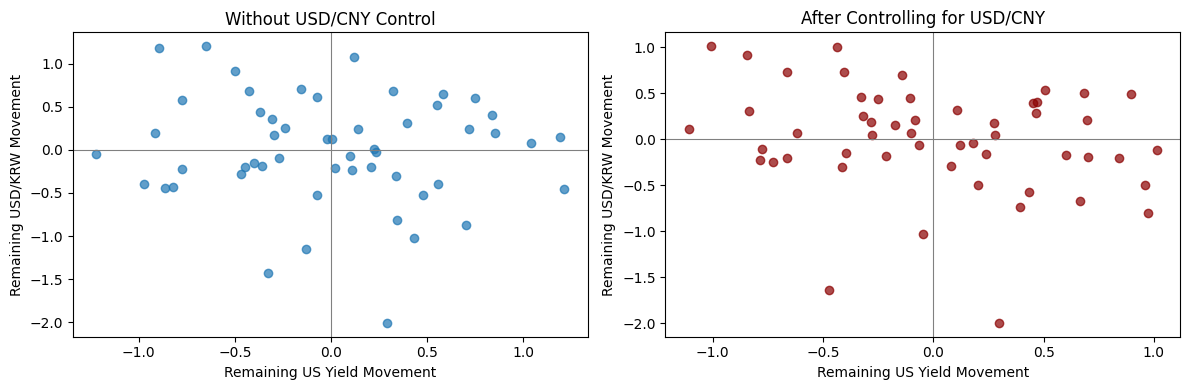

In [ ]:
# Use the same post-tightening sample
variables_needed = [
    "USD_KRW_Change_Pct",
    "US_3Y_Change_Lag1",
    "Korea_3Y_Change_Lag1",
    "DXY_Change_Pct",
    "VIX_Change_Pct",
    "USD_CNY_Change_Pct"
]

suppression_sample = monthly_data[
    monthly_data["Regime"] == "Post-Tightening"
][variables_needed].dropna().copy()

# Standardize everything
z = (
    suppression_sample - suppression_sample.mean()
) / suppression_sample.std()

# First, show the ordinary correlations
print("Ordinary correlations:")
display(z.corr().round(3))


def get_residuals(target, controls):
    """
    Removes the portion of the target variable
    explained by the listed controls.
    """
    X = sm.add_constant(z[controls])
    model = sm.OLS(z[target], X).fit()
    return model.resid


# Relationship after controlling for Korea yield, DXY and VIX
controls_without_cny = [
    "Korea_3Y_Change_Lag1",
    "DXY_Change_Pct",
    "VIX_Change_Pct"
]

usdkrw_resid_without_cny = get_residuals(
    "USD_KRW_Change_Pct",
    controls_without_cny
)

usyield_resid_without_cny = get_residuals(
    "US_3Y_Change_Lag1",
    controls_without_cny
)

partial_corr_without_cny = (
    usdkrw_resid_without_cny.corr(
        usyield_resid_without_cny
    )
)


# Repeat after also controlling for USD/CNY
controls_with_cny = controls_without_cny + [
    "USD_CNY_Change_Pct"
]

usdkrw_resid_with_cny = get_residuals(
    "USD_KRW_Change_Pct",
    controls_with_cny
)

usyield_resid_with_cny = get_residuals(
    "US_3Y_Change_Lag1",
    controls_with_cny
)

partial_corr_with_cny = (
    usdkrw_resid_with_cny.corr(
        usyield_resid_with_cny
    )
)


comparison = pd.DataFrame({
    "Test": [
        "Without controlling for USD/CNY",
        "After controlling for USD/CNY"
    ],
    "Partial_Correlation": [
        partial_corr_without_cny,
        partial_corr_with_cny
    ]
})

display(comparison.round(4))


# Visual comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(
    usyield_resid_without_cny,
    usdkrw_resid_without_cny,
    alpha=0.7
)

axes[0].set_title("Without USD/CNY Control")
axes[0].set_xlabel("Remaining US Yield Movement")
axes[0].set_ylabel("Remaining USD/KRW Movement")
axes[0].axhline(0, color="gray", linewidth=0.8)
axes[0].axvline(0, color="gray", linewidth=0.8)

axes[1].scatter(
    usyield_resid_with_cny,
    usdkrw_resid_with_cny,
    alpha=0.7,
    color="darkred"
)

axes[1].set_title("After Controlling for USD/CNY")
axes[1].set_xlabel("Remaining US Yield Movement")
axes[1].set_ylabel("Remaining USD/KRW Movement")
axes[1].axhline(0, color="gray", linewidth=0.8)
axes[1].axvline(0, color="gray", linewidth=0.8)

plt.tight_layout()
plt.show()


### 7.5 Outlier Diagnostics (Cook's Distance)

In [ ]:
# Variables in the complete post-tightening model
full_drivers = [
    "US_3Y_Change_Lag1",
    "Korea_3Y_Change_Lag1",
    "DXY_Change_Pct",
    "VIX_Change_Pct",
    "USD_CNY_Change_Pct"
]

# Use the same clean post-tightening sample
outlier_sample = monthly_data[
    monthly_data["Regime"] == "Post-Tightening"
].dropna(
    subset=["USD_KRW_Change_Pct"] + full_drivers
).copy()

# Standardize the variables
z_outlier = outlier_sample[
    ["USD_KRW_Change_Pct"] + full_drivers
].apply(lambda column: (column - column.mean()) / column.std())

y_full = z_outlier["USD_KRW_Change_Pct"]
X_full = sm.add_constant(z_outlier[full_drivers])

# Regular OLS model for measuring observation influence
influence_model = sm.OLS(y_full, X_full).fit()

# Calculate Cook's distance for every month
influence = influence_model.get_influence()
cooks_distance = influence.cooks_distance[0]

outlier_sample["Cooks_Distance"] = cooks_distance

# Common screening threshold
cooks_threshold = 4 / len(outlier_sample)

influential_months = outlier_sample[
    outlier_sample["Cooks_Distance"] > cooks_threshold
].copy()

print("Cook's distance threshold:", round(cooks_threshold, 4))
print("Number of influential months:", len(influential_months))

display(
    influential_months[
        [
            "USD_KRW_Change_Pct",
            "US_3Y_Change_Lag1",
            "Korea_3Y_Change_Lag1",
            "DXY_Change_Pct",
            "VIX_Change_Pct",
            "USD_CNY_Change_Pct",
            "Cooks_Distance"
        ]
    ].sort_values(
        "Cooks_Distance",
        ascending=False
    ).round(4)
)


# Estimate the original model with HAC standard errors
original_model = sm.OLS(
    y_full,
    X_full
).fit(
    cov_type="HAC",
    cov_kwds={"maxlags": 3}
)


# Remove influential months temporarily
keep_month = (
    outlier_sample["Cooks_Distance"] <= cooks_threshold
)

y_reduced = y_full.loc[keep_month]
X_reduced = X_full.loc[keep_month]

reduced_model = sm.OLS(
    y_reduced,
    X_reduced
).fit(
    cov_type="HAC",
    cov_kwds={"maxlags": 3}
)


# Compare the US-yield result
outlier_comparison = pd.DataFrame({
    "Model": [
        "All months",
        "Without influential months"
    ],
    "Observations": [
        int(original_model.nobs),
        int(reduced_model.nobs)
    ],
    "US_Yield_Coefficient": [
        original_model.params["US_3Y_Change_Lag1"],
        reduced_model.params["US_3Y_Change_Lag1"]
    ],
    "US_Yield_P_Value": [
        original_model.pvalues["US_3Y_Change_Lag1"],
        reduced_model.pvalues["US_3Y_Change_Lag1"]
    ],
    "R_Squared": [
        original_model.rsquared,
        reduced_model.rsquared
    ],
    "Adjusted_R_Squared": [
        original_model.rsquared_adj,
        reduced_model.rsquared_adj
    ]
})

display(outlier_comparison.round(4))


Cook's distance threshold: 0.0755
Number of influential months: 4


,USD_KRW_Change_Pct,US_3Y_Change_Lag1,Korea_3Y_Change_Lag1,DXY_Change_Pct,VIX_Change_Pct,USD_CNY_Change_Pct,Cooks_Distance
2022-04-30,5.1097,0.83,0.421,4.7299,62.4514,4.3979,0.1590
2023-05-31,-1.4634,-0.06,0.023,2.6065,13.6882,2.2637,0.1235
2025-05-31,-4.2448,-0.31,-0.302,-0.1407,-24.8178,-0.8983,0.0794
2023-04-30,3.3081,-0.70,-0.527,-0.8194,-15.6150,0.7554,0.0761


,Model,Observations,US_Yield_Coefficient,US_Yield_P_Value,R_Squared,Adjusted_R_Squared
0,All months,53,-0.2530,0.0373,0.6849,0.6514
1,Without influential months,49,-0.2023,0.0775,0.7695,0.7427


### 7.6 Correcting for Regime Look-Ahead in Lagged Values

In [ ]:
# Corrected lagged sample:
# Start in May 2022 so every lagged yield observation
# comes from the post-tightening period

corrected_post = monthly_data[
    monthly_data.index >= "2022-05-01"
].dropna(
    subset=["USD_KRW_Change_Pct"] + full_drivers
).copy()

# Standardize variables
z_corrected = corrected_post[
    ["USD_KRW_Change_Pct"] + full_drivers
].apply(
    lambda column:
    (column - column.mean()) / column.std()
)

y_corrected = z_corrected["USD_KRW_Change_Pct"]
X_corrected = sm.add_constant(
    z_corrected[full_drivers]
)

# Corrected full model
corrected_model = sm.OLS(
    y_corrected,
    X_corrected
).fit(
    cov_type="HAC",
    cov_kwds={"maxlags": 3}
)

corrected_result = pd.DataFrame({
    "Observations": [int(corrected_model.nobs)],
    "US_Yield_Coefficient": [
        corrected_model.params["US_3Y_Change_Lag1"]
    ],
    "US_Yield_P_Value": [
        corrected_model.pvalues["US_3Y_Change_Lag1"]
    ],
    "Korea_Yield_Coefficient": [
        corrected_model.params["Korea_3Y_Change_Lag1"]
    ],
    "Korea_Yield_P_Value": [
        corrected_model.pvalues["Korea_3Y_Change_Lag1"]
    ],
    "R_Squared": [corrected_model.rsquared],
    "Adjusted_R_Squared": [
        corrected_model.rsquared_adj
    ]
})

display(corrected_result.round(4))


,Observations,US_Yield_Coefficient,US_Yield_P_Value,Korea_Yield_Coefficient,Korea_Yield_P_Value,R_Squared,Adjusted_R_Squared
0,52,-0.1912,0.0905,0.1004,0.3575,0.6816,0.647


## 8. Weekly-Frequency Robustness Check

As a final check, we rebuild the full driver set at weekly frequency to see whether the monthly-frequency findings hold up at a finer time resolution.


In [ ]:
# Combine the original daily datasets
weekly_data = pd.concat(
    [
        usdkrw_daily,
        us_3y,
        korea_3y_daily,
        dxy_daily,
        vix_daily,
        usdcny_daily
    ],
    axis=1
).sort_index()

# Use the final available observation in each Friday-ending week
weekly_data = weekly_data.resample("W-FRI").last()

# Match the end date of the monthly analysis
weekly_data = weekly_data.loc[:WEEKLY_END].copy()

# Construct the US-Korea yield differential
weekly_data["Rate_Differential"] = (
    weekly_data["US_3Y_Yield"]
    - weekly_data["Korea_3Y_Yield"]
)

# Calculate weekly movements
weekly_data["USD_KRW_Change_Pct"] = (
    weekly_data["USD_KRW"].pct_change() * 100
)

weekly_data["Rate_Diff_Change"] = (
    weekly_data["Rate_Differential"].diff()
)

weekly_data["DXY_Change_Pct"] = (
    weekly_data["DXY"].pct_change() * 100
)

weekly_data["VIX_Change_Pct"] = (
    weekly_data["VIX"].pct_change() * 100
)

weekly_data["USD_CNY_Change_Pct"] = (
    weekly_data["USD_CNY"].pct_change() * 100
)

# Define the regimes
weekly_data["Regime"] = "Transition Month"

weekly_data.loc[
    weekly_data.index < "2022-03-01",
    "Regime"
] = "Pre-Tightening"

weekly_data.loc[
    weekly_data.index >= "2022-04-01",
    "Regime"
] = "Post-Tightening"

weekly_drivers = [
    "Rate_Diff_Change",
    "DXY_Change_Pct",
    "VIX_Change_Pct",
    "USD_CNY_Change_Pct"
]

weekly_results = []

for regime in ["Pre-Tightening", "Post-Tightening"]:

    sample = weekly_data[
        weekly_data["Regime"] == regime
    ].dropna(
        subset=["USD_KRW_Change_Pct"] + weekly_drivers
    )

    # Standardize variables for coefficient comparison
    y = sample["USD_KRW_Change_Pct"]
    y = (y - y.mean()) / y.std()

    X = sample[weekly_drivers]
    X = (X - X.mean()) / X.std()
    X = sm.add_constant(X)

    # HAC errors account for weekly time-series dependence
    model = sm.OLS(y, X).fit(
        cov_type="HAC",
        cov_kwds={"maxlags": 4}
    )

    for driver in weekly_drivers:
        weekly_results.append({
            "Regime": regime,
            "Weeks": int(model.nobs),
            "Driver": driver,
            "Standardized_Coefficient":
                model.params[driver],
            "P_Value":
                model.pvalues[driver],
            "R_Squared":
                model.rsquared,
            "Adjusted_R_Squared":
                model.rsquared_adj
        })

weekly_results_table = pd.DataFrame(weekly_results)

display(weekly_results_table.round(4))


,Regime,Weeks,Driver,Standardized_Coefficient,P_Value,R_Squared,Adjusted_R_Squared
0,Pre-Tightening,318,Rate_Diff_Change,-0.0063,0.9029,0.3323,0.3238
1,Pre-Tightening,318,DXY_Change_Pct,0.3358,0.0000,0.3323,0.3238
2,Pre-Tightening,318,VIX_Change_Pct,0.1865,0.0011,0.3323,0.3238
3,Pre-Tightening,318,USD_CNY_Change_Pct,0.3080,0.0000,0.3323,0.3238
4,Post-Tightening,231,Rate_Diff_Change,-0.0361,0.5334,0.4495,0.4398
5,Post-Tightening,231,DXY_Change_Pct,0.4489,0.0000,0.4495,0.4398
6,Post-Tightening,231,VIX_Change_Pct,0.0888,0.0522,0.4495,0.4398
7,Post-Tightening,231,USD_CNY_Change_Pct,0.3308,0.0000,0.4495,0.4398


### Summary of Robustness Checks

Evidence for a stable interest-rate relationship is **not robust across every specification**:

- In the corrected lagged monthly model, the previous month's US yield change is only marginally significant (`p = 0.0905`), while the Korean yield change is not significant.
- Removing influential months also weakens the apparent lagged US-yield result.
- At weekly frequency, the yield-gap change is not significant in either regime.
- DXY and USD/CNY remain the most stable drivers across frequencies; VIX becomes weaker after tightening.

This makes the responsible conclusion more nuanced: the role of rates appears frequency- and specification-dependent, while broad-dollar and regional-currency effects are more reliable.


## 9. Final Comparison Chart

This chart compares standardized coefficients from the primary monthly model. Asterisks identify coefficients with `p < 0.05`; they do not imply causality.


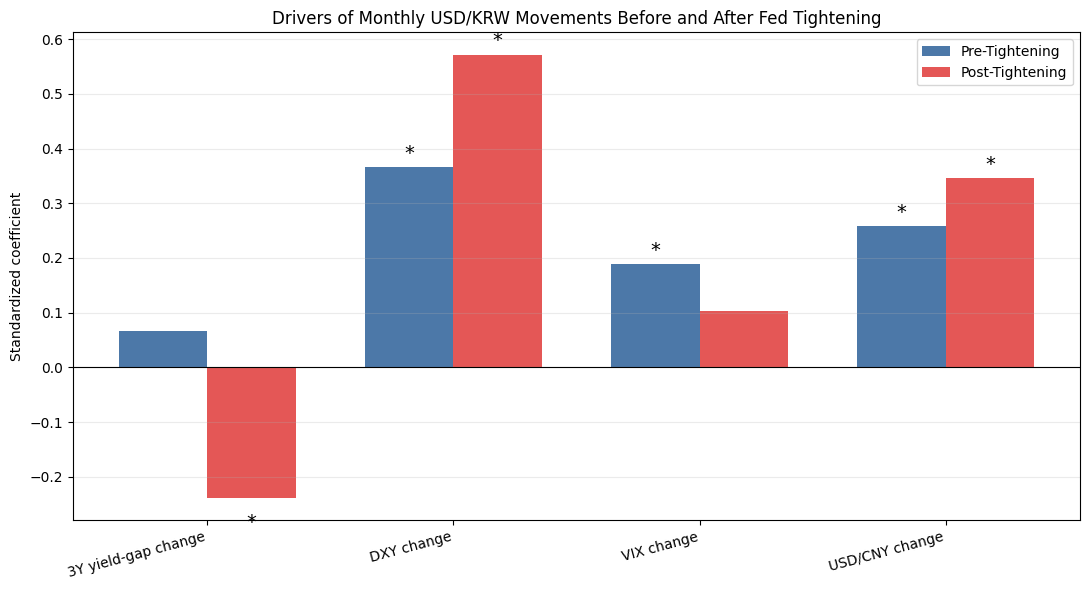

In [ ]:
plot_data = coefficient_table.copy()
plot_data["Label"] = plot_data["Driver"].replace({
    "Rate_Diff_Change": "3Y yield-gap change",
    "DXY_Change_Pct": "DXY change",
    "VIX_Change_Pct": "VIX change",
    "USD_CNY_Change_Pct": "USD/CNY change"
})

fig, ax = plt.subplots(figsize=(11, 6))
order = ["3Y yield-gap change", "DXY change", "VIX change", "USD/CNY change"]
x = range(len(order))
width = 0.36

for offset, regime, color in [(-width/2, "Pre-Tightening", "#4C78A8"),
                              ( width/2, "Post-Tightening", "#E45756")]:
    subset = plot_data.set_index(["Regime", "Label"]).loc[regime]
    values = [subset.loc[label, "Standardized_Coefficient"] for label in order]
    bars = ax.bar([i + offset for i in x], values, width, label=regime, color=color)
    for bar, label in zip(bars, order):
        p = subset.loc[label, "P_Value"]
        if p < 0.05:
            y = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2, y + (0.025 if y >= 0 else -0.045),
                    "*", ha="center", va="center", fontsize=14)

ax.axhline(0, color="black", linewidth=0.8)
ax.set_xticks(list(x))
ax.set_xticklabels(order, rotation=15, ha="right")
ax.set_ylabel("Standardized coefficient")
ax.set_title("Drivers of Monthly USD/KRW Movements Before and After Fed Tightening")
ax.legend()
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()


## 10. Conclusion

### Answer to the Research Question

The estimated relationships between USD/KRW and the selected market variables differ between the pre- and post-tightening samples. The expanded monthly model's explanatory power rose from about **40% before tightening to 70% after tightening**, indicating a stronger in-sample fit in the later regime. These R² values do not establish out-of-sample predictive accuracy.

The starting hypothesis receives **partial, but not robust, support**. In the main monthly model, the change in the US–Korea 3-year yield differential becomes significant after tightening. However, the sign is negative. Related evidence from lagged yield models weakens after correcting the sample boundary and removing influential months, while the contemporaneous yield-gap relationship disappears at weekly frequency. It would therefore be misleading to claim that the yield gap alone drove the won.

The clearest result is that **broad US-dollar strength (DXY) is the strongest and most consistent post-tightening driver**, with **USD/CNY** also retaining a meaningful association. VIX matters more clearly before tightening and becomes weaker afterward. Overall, USD/KRW appears to have become more tightly connected to global-dollar and regional-currency conditions, while the measured rate effect depends on the model and time horizon.

### What This Project Does — and Does Not — Show

- It identifies conditional associations and compares them across two market regimes.
- It does not estimate a structural fair value or prove causality.
- The March 2022 split is economically motivated but still a researcher's choice.
- Monthly post-tightening results use a relatively small sample, and overlapping market proxies can complicate interpretation.
- Daily market closes across countries are not perfectly synchronized.

### Future Research: Foreign Equity Flows

Foreign investors' net purchases of Korean equities are a plausible omitted variable because cross-border transactions may generate currency-conversion demand. They were not included in the primary model because consistent investor-flow data required separate sourcing and cleaning beyond the project's initial scope. KOSPI returns were not used as a substitute because market performance does not directly measure foreign buying and selling. Future analysis could test whether actual foreign net-purchase flows add explanatory power beyond DXY, VIX, USD/CNY, and interest-rate variables, while accounting for possible reverse causality between exchange rates and investment decisions.
